In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from torchvision import models
import ssl

from glob import glob
from PIL import Image
import random
import os
import pandas as pd

## load dữ liệu và chia dữ liệu theo tỉ lệ 90:5:5

In [13]:
# Định nghĩa đường dẫn thư mục chứa dữ liệu
data_dir = "data/images"
train_data, valid_data, test_data = [], [], []
label_map = {}  # Mapping nhãn -> số

for label_idx, label in enumerate(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    
    # Lưu ánh xạ nhãn
    label_map[label] = label_idx
    
    # Lấy danh sách ảnh và sắp xếp để đảm bảo đúng thứ tự
    image_paths = sorted(glob(os.path.join(label_path, "*")))
    
    # Chia thành hai phần: loại ảnh 1 (2500 ảnh đầu) và loại ảnh 2 (2500 ảnh cuối)
    type1_images = image_paths[:2500]
    type2_images = image_paths[2500:]

    def split_data(image_list):
        """Chia dữ liệu theo tỷ lệ 90:5:5"""
        total = len(image_list)
        train_split = int(0.9 * total)
        valid_split = int(0.95 * total)

        return (
            [(p, label_idx) for p in image_list[:train_split]],  # Train
            [(p, label_idx) for p in image_list[train_split:valid_split]],  # Valid
            [(p, label_idx) for p in image_list[valid_split:]]  # Test
        )

    # Chia dữ liệu đều cho từng loại ảnh
    train_1, valid_1, test_1 = split_data(type1_images)
    train_2, valid_2, test_2 = split_data(type2_images)

    # Ghép hai phần lại với nhau
    train_data.extend(train_1 + train_2)
    valid_data.extend(valid_1 + valid_2)
    test_data.extend(test_1 + test_2)

In [14]:
# Kiểm tra số lượng mẫu mỗi tập
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

# Hiển thị một số đường dẫn ảnh từ mỗi tập (kiểm tra kết quả)
print("Sample train images:", train_data[:3])
print("Sample valid images:", valid_data[:3])
print("Sample test images:", test_data[:3])
print("labels: ", label_map)

Train: 18000, Valid: 1000, Test: 1000
Sample train images: [('data/images\\BENIGN\\0.png', 0), ('data/images\\BENIGN\\1.png', 0), ('data/images\\BENIGN\\10.png', 0)]
Sample valid images: [('data/images\\BENIGN\\3022.png', 0), ('data/images\\BENIGN\\3023.png', 0), ('data/images\\BENIGN\\3024.png', 0)]
Sample test images: [('data/images\\BENIGN\\3135.png', 0), ('data/images\\BENIGN\\3136.png', 0), ('data/images\\BENIGN\\3137.png', 0)]
labels:  {'BENIGN': 0, 'Group1': 1, 'Group2': 2, 'Syn': 3}


## train

In [15]:
# Định nghĩa Dataset
class ImageDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [16]:
# Định nghĩa các phép biến đổi dữ liệu
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize ảnh về kích thước chuẩn
    transforms.ToTensor(), # Chuyển ảnh thành tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa theo ImageNet
])

# Tạo DataLoader
batch_size = 32
train_loader = DataLoader(ImageDataset(train_data, transform), batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(ImageDataset(valid_data, transform), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(ImageDataset(test_data, transform), batch_size=batch_size, shuffle=False)

# Số lớp đầu ra
num_classes = len(label_map.keys())
print(num_classes)

4


In [17]:
# Kiểm tra thiết bị (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [18]:
# Sử dụng khi thuê GPU trên máy ảo để tải base model
ssl._create_default_https_context = ssl._create_unverified_context

In [19]:
# Load mô hình AlexNet
model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

In [20]:
model = models.alexnet(pretrained=True)
model.classifier[6] = nn.Linear(4096, num_classes) 
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

In [21]:
# Huấn luyện mô hình
num_epochs = 20
train_loss, valid_loss = [], []
train_acc, valid_acc = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    train_loss.append(running_loss / total)
    train_acc.append(correct / total)
    
    # Validation
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    valid_loss.append(running_loss / total)
    valid_acc.append(correct / total)
    
    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_acc[-1]:.4f}, Valid Loss: {valid_loss[-1]:.4f}, Valid Acc: {valid_acc[-1]:.4f}")


Epoch 1/20: Train Loss: 0.1081, Train Acc: 0.9679, Valid Loss: 0.1134, Valid Acc: 0.9570
Epoch 2/20: Train Loss: 0.0627, Train Acc: 0.9823, Valid Loss: 0.0791, Valid Acc: 0.9610
Epoch 3/20: Train Loss: 0.0534, Train Acc: 0.9831, Valid Loss: 0.0778, Valid Acc: 0.9590
Epoch 4/20: Train Loss: 0.0465, Train Acc: 0.9845, Valid Loss: 0.0969, Valid Acc: 0.9530
Epoch 5/20: Train Loss: 0.0470, Train Acc: 0.9849, Valid Loss: 0.0721, Valid Acc: 0.9620
Epoch 6/20: Train Loss: 0.0360, Train Acc: 0.9875, Valid Loss: 0.0410, Valid Acc: 0.9840
Epoch 7/20: Train Loss: 0.0287, Train Acc: 0.9894, Valid Loss: 0.0441, Valid Acc: 0.9850
Epoch 8/20: Train Loss: 0.0260, Train Acc: 0.9898, Valid Loss: 0.0325, Valid Acc: 0.9880
Epoch 9/20: Train Loss: 0.0333, Train Acc: 0.9889, Valid Loss: 0.0398, Valid Acc: 0.9830
Epoch 10/20: Train Loss: 0.0273, Train Acc: 0.9885, Valid Loss: 0.0827, Valid Acc: 0.9810
Epoch 11/20: Train Loss: 0.0269, Train Acc: 0.9912, Valid Loss: 0.0313, Valid Acc: 0.9880
Epoch 12/20: Train 

In [22]:
# Lưu mô hình
torch.save(model.state_dict(), "models/alexnet_finetuned.pth")

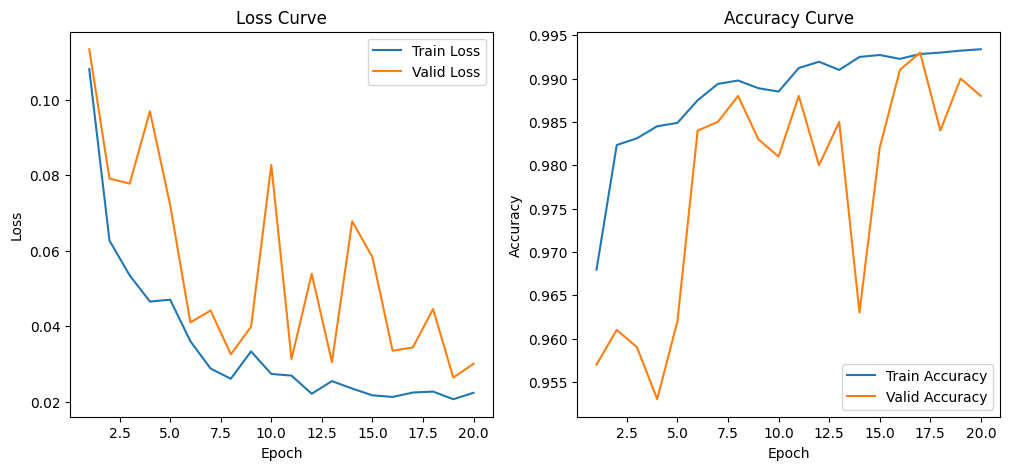

In [23]:
# Vẽ Loss Curve và Accuracy Curve
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_loss, label="Train Loss")
plt.plot(range(1, num_epochs+1), valid_loss, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), train_acc, label="Train Accuracy")
plt.plot(range(1, num_epochs+1), valid_acc, label="Valid Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()


## đánh giá

In [25]:
# Định nghĩa đường dẫn thư mục chứa dữ liệu
data_dir = "data/images"
train_data, valid_data, test_data = [], [], []
label_map = {}  # Mapping nhãn -> số

for label_idx, label in enumerate(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    
    # Lưu ánh xạ nhãn
    label_map[label] = label_idx
    
    # Lấy danh sách ảnh và sắp xếp để đảm bảo đúng thứ tự
    image_paths = sorted(glob(os.path.join(label_path, "*")))
    
    # Chia thành hai phần: loại ảnh 1 (2500 ảnh đầu) và loại ảnh 2 (2500 ảnh cuối)
    type1_images = image_paths[:2500]
    type2_images = image_paths[2500:]

    def split_data(image_list):
        """Chia dữ liệu theo tỷ lệ 90:5:5"""
        total = len(image_list)
        train_split = int(0.9 * total)
        valid_split = int(0.95 * total)

        return (
            [(p, label_idx) for p in image_list[:train_split]],  # Train
            [(p, label_idx) for p in image_list[train_split:valid_split]],  # Valid
            [(p, label_idx) for p in image_list[valid_split:]]  # Test
        )

    # Chia dữ liệu đều cho từng loại ảnh
    train_1, valid_1, test_1 = split_data(type1_images)
    train_2, valid_2, test_2 = split_data(type2_images)

    # Ghép hai phần lại với nhau
    train_data.extend(train_1 + train_2)
    valid_data.extend(valid_1 + valid_2)
    test_data.extend(test_1 + test_2)
    
# Kiểm tra số lượng mẫu mỗi tập
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

# Hiển thị một số đường dẫn ảnh từ mỗi tập (kiểm tra kết quả)
print("Sample train images:", train_data[:3])
print("Sample valid images:", valid_data[:3])
print("Sample test images:", test_data[:3])
print("labels: ", label_map)

# Định nghĩa Dataset
class ImageDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Định nghĩa các phép biến đổi dữ liệu
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize ảnh về kích thước chuẩn
    transforms.ToTensor(), # Chuyển ảnh thành tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa theo ImageNet
])

# Tạo DataLoader
batch_size = 32
test_loader = DataLoader(ImageDataset(test_data, transform), batch_size=batch_size, shuffle=False)

# Số lớp đầu ra
num_classes = len(label_map.keys())
print(num_classes)
    
# Kiểm tra thiết bị (GPU nếu có)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print("Using device:", device)


Train: 18000, Valid: 1000, Test: 1000
Sample train images: [('data/images\\BENIGN\\0.png', 0), ('data/images\\BENIGN\\1.png', 0), ('data/images\\BENIGN\\10.png', 0)]
Sample valid images: [('data/images\\BENIGN\\3022.png', 0), ('data/images\\BENIGN\\3023.png', 0), ('data/images\\BENIGN\\3024.png', 0)]
Sample test images: [('data/images\\BENIGN\\3135.png', 0), ('data/images\\BENIGN\\3136.png', 0), ('data/images\\BENIGN\\3137.png', 0)]
labels:  {'BENIGN': 0, 'Group1': 1, 'Group2': 2, 'Syn': 3}
4
Using device: cpu


In [26]:
model = models.alexnet(pretrained=True)
model.classifier[6] = torch.nn.Linear(4096, num_classes)
model.load_state_dict(torch.load("models/alexnet_finetuned.pth", map_location=device))
model = model.to(device)
model.eval()
print(len(label_map.keys()))

4


In [27]:
# Kiểm thử trên tập test
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [28]:
# Tính độ chính xác trên tập test
test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9920


In [29]:
# Classification Report
print(classification_report(y_true, y_pred, target_names=label_map.keys()))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00       250
      Group1       0.98      1.00      0.99       250
      Group2       0.99      0.98      0.99       250
         Syn       1.00      0.99      0.99       250

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



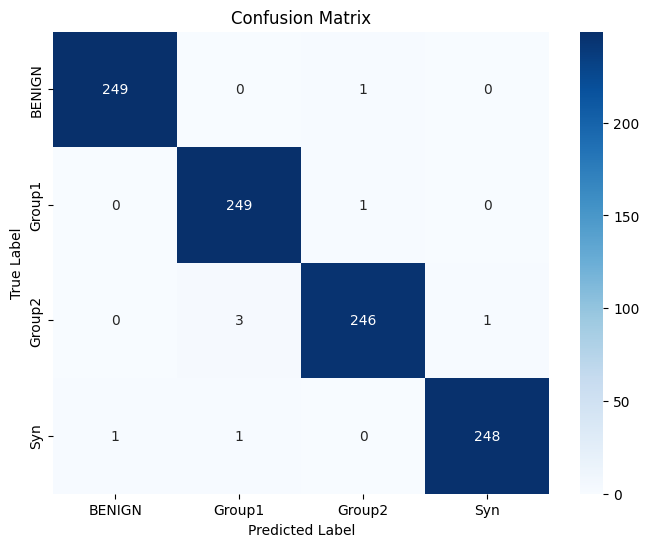

In [30]:
# Vẽ Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

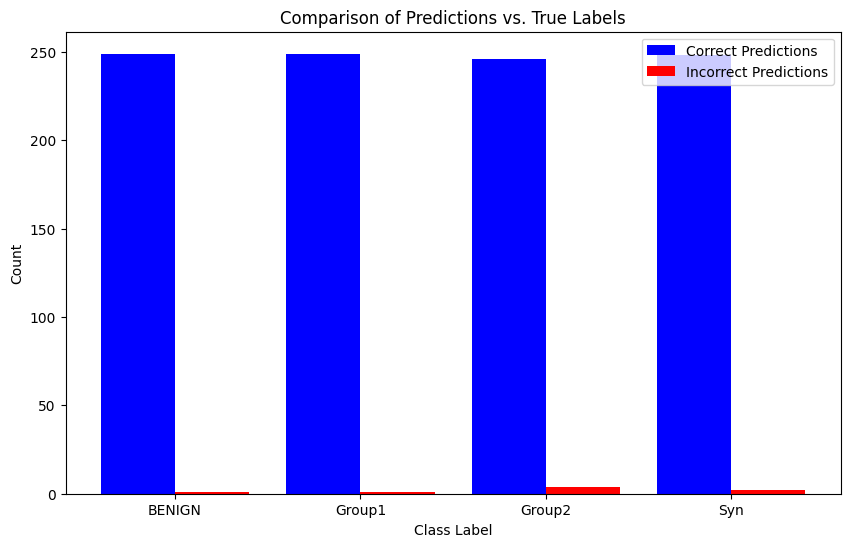

In [31]:
# Vẽ biểu đồ so sánh dự đoán với nhãn thực tế
# correct = (np.array(y_true) == np.array(y_pred))
# plt.figure(figsize=(10,5))
# sns.histplot(data={'Actual': y_true, 'Predicted': y_pred, 'Correct': correct}, x='Actual', hue='Correct', multiple='stack', discrete=True)
# plt.xlabel("Actual Label")
# plt.ylabel("Count")
# plt.title("Comparison of Predictions vs Actual Labels")
# plt.legend(["Incorrect", "Correct"], title="Prediction")
# plt.show()


# Tạo DataFrame chứa nhãn thực tế và dự đoán
df = pd.DataFrame({"True Label": y_true, "Predicted Label": y_pred})

# Đếm số lượng dự đoán đúng và sai theo từng lớp
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

# Đếm số lượng đúng/sai theo từng lớp
correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

# Đảm bảo tất cả nhãn có trong bảng
correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()

In [9]:
# Test individual images
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')


# Test individual images
def total_predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    return class_names[predicted.item()]

In [10]:
labels_list = list(label_map.keys())
print(labels_list)

# predict_image(model, "data/test/SYN/1.png", list(label_map.keys()))
# predict_image(model, "data/test/haa/rrr.png", list(label_map.keys()))

# predict_image(model, "data/cic_ddos_2019_images/Syn/4343.png", list(label_map.keys()))

# thống kê chi tiết tên nhãn dự đoán
for i in range(0, len(labels_list)):
    name_details_dict = {}

    for j in test_data:
        if j[1] == i:
            r = total_predict_image(model, f"{j[0]}", labels_list)
            if r in name_details_dict:
                name_details_dict[r] += 1
            else:
                name_details_dict[r] = 1

    print(f'Label: {labels_list[i]}', name_details_dict)



['BENIGN', 'Group1', 'Group2', 'Syn']
Label: BENIGN {'BENIGN': 250}
Label: Group1 {'Group1': 226, 'Group2': 24}
Label: Group2 {'Group2': 245, 'BENIGN': 3, 'Group1': 2}
Label: Syn {'Syn': 250}
